Text(0.5, 0, 'Frequency (Hz)')

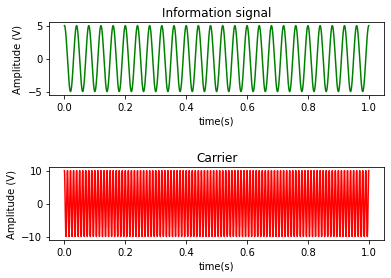

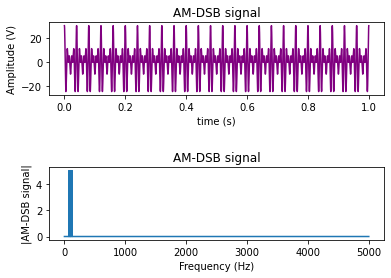

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Nov 20 10:40:48 2020

@author: samir
"""

import numpy as np
import matplotlib.pyplot as plt


samplingFrequency   = 10000;
samplingInterval    = 1 / samplingFrequency;
beginTime           = 0;
endTime             = 1; 
t                    = np.arange(beginTime, endTime, samplingInterval);

A_c = 10
f_c = 100
A_m = 5
f_m = 25
m = 0.8
k = m*A_m/A_c

carrier = A_c*np.cos(2*np.pi*f_c*t)
info = A_m*np.cos(2*np.pi*f_m*t) 
signal_AM = (1+k*info)*A_c*np.cos(2*np.pi*f_c*t) #modulation

# Frequency domain representation
fourierTransform = np.fft.fft(signal_AM)/len(signal_AM)           # Normalize amplitude
fourierTransform = fourierTransform[range(int(len(signal_AM)/2))] # Exclude sampling frequency
tpCount     = len(signal_AM)
values      = np.arange(int(tpCount/2))
timePeriod  = tpCount/samplingFrequency
frequencies = values/timePeriod


figure, axis = plt.subplots(2, 1)
plt.subplots_adjust(hspace=1)


axis[0].plot(t,info,'g')
axis[0].set_title('Information signal')
axis[0].set_ylabel('Amplitude (V)')
axis[0].set_xlabel('time(s)')

axis[1].plot(t,carrier, 'r')
axis[1].set_title('Carrier')
axis[1].set_ylabel('Amplitude (V)')
axis[1].set_xlabel('time(s)')

figure, axis = plt.subplots(2, 1)
plt.subplots_adjust(hspace=1)

axis[0].plot(t,signal_AM, color="purple")
axis[0].set_title('AM-DSB signal')
axis[0].set_ylabel('Amplitude (V)')
axis[0].set_xlabel('time (s)')

axis[1].plot(frequencies, abs(fourierTransform))
axis[1].set_title('AM-DSB signal')
axis[1].set_ylabel("|AM-DSB signal|")
axis[1].set_xlabel("Frequency (Hz)")


